# This is a short script to do IV plots for the first orbit at different temperature

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from plot_module.solsim_analyzer import solarSimulator

In [2]:
folderPath_px6 = ""  # Enter your file path/folder path in this place

In [3]:
analyzer = solarSimulator(folderPath=folderPath_px6)
analyzer.loadFolderData_Cycling()

Line 6: # Measured Temperature: 63.06 C
[-0.14464114 -0.94704762 -1.63390574 -2.12164875 -2.48489573 -2.80279396
 -3.03336818 -3.16053175 -3.27768825 -3.40769068 -3.49228561 -3.5061804
 -3.57483142 -3.5930365  -3.56274789 -3.5416266  -3.55502852 -3.54347578
 -3.50251937 -3.45130109 -3.43105695 -3.420822   -3.38512734 -3.315192
 -3.29404347 -3.22055657 -3.1481765  -3.09223584 -3.08158272 -3.0106665
 -2.9249695  -2.88192857 -2.86519587 -2.81062837 -2.71959568 -2.68001444
 -2.65314655 -2.57890621 -2.52975876 -2.5039404  -2.38111243 -2.31792547
 -2.28099021 -2.19575135 -2.12352923 -2.0944541  -2.03171281 -1.95672828
 -1.91019585 -1.86939005 -1.80486892 -1.73296285 -1.68668272 -1.63656976
 -1.57548106 -1.51149651 -1.47454938 -1.42210137 -1.35329352 -1.28829396
 -1.24341135 -1.18977815 -1.12938576 -1.07279605 -1.01241428 -0.95523232
 -0.89730067 -0.84674486 -0.79481155 -0.73135738 -0.67369243 -0.50990276
 -0.45141759 -0.39445454 -0.33504019 -0.2785004  -0.22347972 -0.10956253
 -0.05223734  0

In [4]:
colors = ['#0d0887', '#9c179e', '#ed7953', '#f0f921', '#fca636', '#f0f921']
Temperature = [19.53, 46.17, 57.53, 63.06, 70.66, 74.51]

In [ ]:
currents_smoothed = []
window = 9
for i in range (0, len(analyzer.PCE)):
    currents_smoothed.append(np.convolve(analyzer.currents[i], np.ones(window)/window, mode='same'))

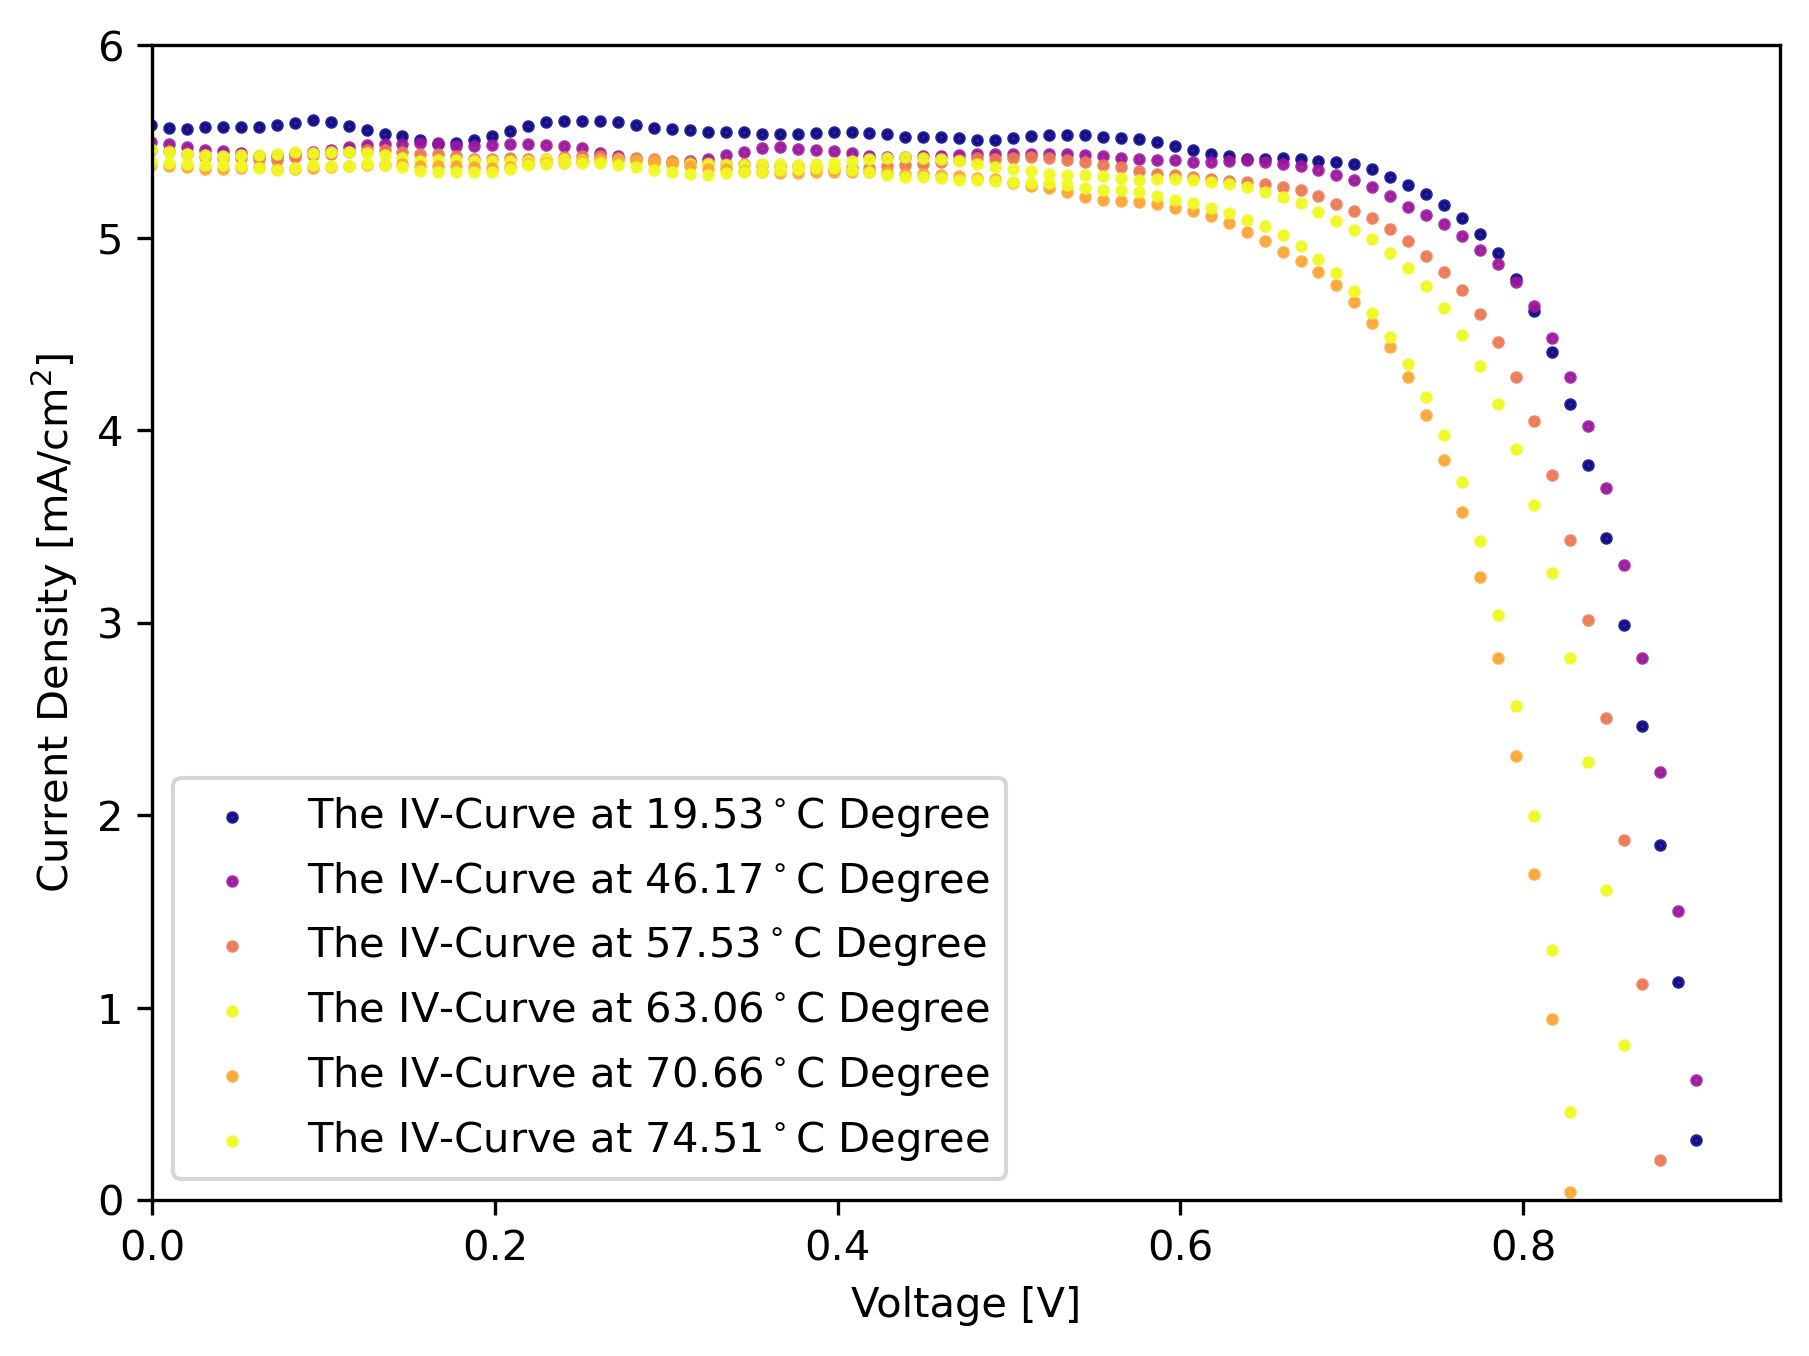

In [6]:
plt.figure(figsize=(7, 5), dpi=300)
for i in range(len(analyzer.PCE)):
    plt.scatter(
        -analyzer.voltages[i],
        #analyzer.currents[i],
        currents_smoothed[i],
        color=colors[i],
        alpha=0.9,
        s=4,   # smaller circles (default ~36),
        label = f"The IV-Curve at {Temperature[i]}$^\circ$C Degree"
    )
plt.xlim(0, 0.95)
plt.ylim(0, 6)
plt.xlabel("Voltage [V]")
plt.ylabel("Current Density [mA/cm$^2$]")
plt.legend()

In [7]:
for i in range (0, len(analyzer.PCE)):
    print("Temperature:", Temperature[i], " PCE:", analyzer.PCE[i], " Isc:", analyzer.Isc[i], " Voc:", analyzer.Voc[i], " FF:", analyzer.FF[i])

Temperature: 19.53  PCE: 17.61006372792345  Isc: 5.597180739706908  Voc: 0.91129  FF: 0.7713943924881872
Temperature: 46.17  PCE: 17.419874100800875  Isc: 5.492198185624563  Voc: 0.91129  FF: 0.7776491336218299
Temperature: 57.53  PCE: 16.57562408854977  Isc: 5.463161200279134  Voc: 0.890323  FF: 0.761412086429368
Temperature: 63.06  PCE: 16.081262604544715  Isc: 5.469155617585484  Voc: 0.869355  FF: 0.7556908998182283
Temperature: 70.66  PCE: 14.915340156025206  Isc: 5.362840195394277  Voc: 0.827419  FF: 0.7510248419241642
Temperature: 74.51  PCE: 15.115290023127647  Isc: 5.371737613398464  Voc: 0.837903  FF: 0.7503250289631221
